CNN CLASSIFIER MODEL USING OHLCV DATA

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5211 - loss: 0.6952 - val_accuracy: 0.4465 - val_loss: 0.7038
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5398 - loss: 0.6913 - val_accuracy: 0.5326 - val_loss: 0.6922
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5405 - loss: 0.6910 - val_accuracy: 0.4576 - val_loss: 0.7003
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5269 - loss: 0.6907 - val_accuracy: 0.4465 - val_loss: 0.7065
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5360 - loss: 0.6893 - val_accuracy: 0.5412 - val_loss: 0.6900
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5260 - loss: 0.6908 - val_accuracy: 0.4539 - val_loss: 0.7135
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5354 - loss: 0.6883 - val_accuracy: 0.4502 - val_loss: 0.7359
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5364 - loss: 0.6875 - val_accuracy: 0.

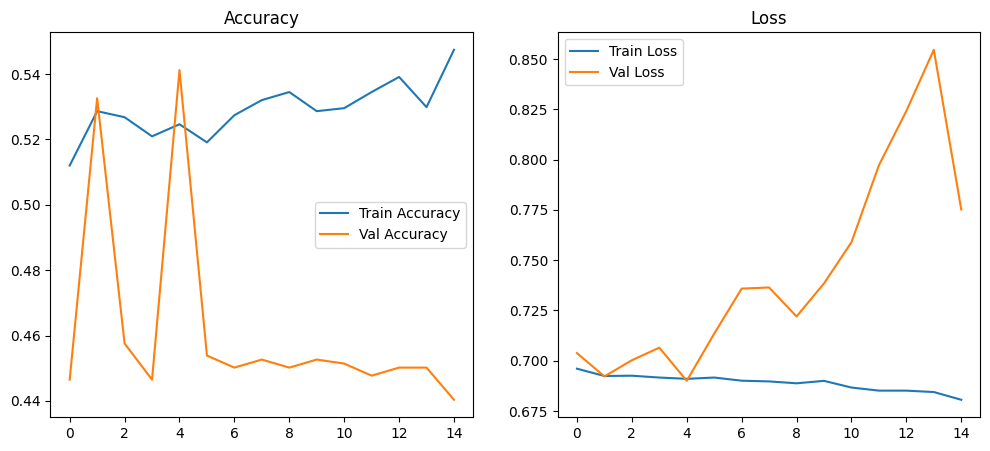

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

# 1. Load and Clean
df = pd.read_csv('NIFTY50.csv')
# Drop rows with any NaN values
df.dropna(inplace=True)

# 2. Feature Engineering
# Target: direction of next day's close price compared to today's close price
# Direction = 1 if Close(t+1) > Close(t), else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Features to use: Open, High, Low, Close, Volume
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[features].values
target = df['Target'].values

# Remove the last row as its target is unknown (shift -1)
data = data[:-1]
target = target[:-1]

# 3. Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 4. Create sequences for CNN
def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : (i + window_size)])
        y.append(target[i + window_size - 1]) # Predict direction of day t+1 based on window ending at day t
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(data_scaled, target, window_size)

# 5. Train-Test Split (Chronological to prevent data leakage)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Build Multi-layer CNN
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, len(features))),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train with Early Stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 8. Evaluation and Plotting
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Plotting Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()